In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [2]:
df_games = pd.read_csv('C:\\Users\\Paul\\sb\\Untitled Folder\\raw_data\\nba_games_all.csv').drop(columns=['matchup',
                                                                                                          'a_team_id', 'wl'])
df_games.head()

,game_id,game_date,team_id,is_home,w,l,w_pct,min,fgm,fga,fg_pct,fg3m,fg3a,fg3_pct,ftm,fta,ft_pct,oreb,dreb,reb,ast,stl,blk,tov,pf,pts,season_year,season_type,season
0,20800741,2009-02-06,1610612762,f,29.0,22.0,0.569,240,39.0,74.0,0.527,4.0,13.0,0.308,29.0,37.0,1.0,8.0,36.0,44,19.0,5.0,4.0,18.0,26.0,111,2008,Regular Season,2008-09
1,20800701,2009-01-31,1610612762,f,26.0,22.0,0.542,240,37.0,68.0,0.544,5.0,20.0,0.250,29.0,37.0,1.0,7.0,20.0,27,17.0,6.0,0.0,15.0,22.0,108,2008,Regular Season,2008-09
2,20800584,2009-01-16,1610612762,f,24.0,16.0,0.600,240,37.0,71.0,0.521,7.0,19.0,0.368,20.0,27.0,1.0,7.0,26.0,33,23.0,9.0,3.0,15.0,22.0,101,2008,Regular Season,2008-09
3,20800558,2009-01-12,1610612762,t,23.0,15.0,0.605,240,39.0,85.0,0.459,8.0,18.0,0.444,34.0,37.0,1.0,9.0,31.0,40,24.0,10.0,6.0,8.0,20.0,120,2008,Regular Season,2008-09
4,20800440,2008-12-27,1610612762,f,18.0,14.0,0.563,290,49.0,100.0,0.490,5.0,13.0,0.385,12.0,18.0,1.0,11.0,29.0,40,35.0,13.0,7.0,9.0,27.0,115,2008,Regular Season,2008-09


In [3]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125624 entries, 0 to 125623
Data columns (total 29 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   game_id      125624 non-null  int64  
 1   game_date    119376 non-null  object 
 2   team_id      125624 non-null  int64  
 3   is_home      125624 non-null  object 
 4   w            41000 non-null   float64
 5   l            41000 non-null   float64
 6   w_pct        41000 non-null   float64
 7   min          125624 non-null  int64  
 8   fgm          125607 non-null  float64
 9   fga          90894 non-null   float64
 10  fg_pct       90871 non-null   float64
 11  fg3m         95248 non-null   float64
 12  fg3a         84316 non-null   float64
 13  fg3_pct      80062 non-null   float64
 14  ftm          125605 non-null  float64
 15  fta          120011 non-null  float64
 16  ft_pct       119960 non-null  float64
 17  oreb         83786 non-null   float64
 18  dreb         83639 non-n

In [4]:
df_games['game_date'] = pd.to_datetime(df_games['game_date'])
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125624 entries, 0 to 125623
Data columns (total 29 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   game_id      125624 non-null  int64         
 1   game_date    119376 non-null  datetime64[ns]
 2   team_id      125624 non-null  int64         
 3   is_home      125624 non-null  object        
 4   w            41000 non-null   float64       
 5   l            41000 non-null   float64       
 6   w_pct        41000 non-null   float64       
 7   min          125624 non-null  int64         
 8   fgm          125607 non-null  float64       
 9   fga          90894 non-null   float64       
 10  fg_pct       90871 non-null   float64       
 11  fg3m         95248 non-null   float64       
 12  fg3a         84316 non-null   float64       
 13  fg3_pct      80062 non-null   float64       
 14  ftm          125605 non-null  float64       
 15  fta          120011 non-null  floa

In [5]:
column_names = df_games.columns
column_names

Index(['game_id', 'game_date', 'team_id', 'is_home', 'w', 'l', 'w_pct', 'min',
       'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta',
       'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'pf',
       'pts', 'season_year', 'season_type', 'season'],
      dtype='object')

In [6]:
column_names = column_names.drop(['game_id', 'game_date', 'is_home', 'season_year', 'season_type', 'season'])
column_names

Index(['team_id', 'w', 'l', 'w_pct', 'min', 'fgm', 'fga', 'fg_pct', 'fg3m',
       'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast',
       'stl', 'blk', 'tov', 'pf', 'pts'],
      dtype='object')

In [7]:
empty_df = df_games[df_games.is_home == 'f']

for column_name in column_names:
    empty_df = empty_df[empty_df.is_home == 'f'].rename(columns={column_name: column_name + '_away'})
    
empty_df = empty_df.drop(columns=['is_home'])

In [8]:
for column_name in column_names:
    df_games = df_games[df_games.is_home == 't'].rename(columns={column_name: column_name + '_home'})
    
df_games = df_games.drop(columns='is_home')

In [9]:
df_games.info() #<<<<<<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>><<<<<<<<<<<<<<<>>>>>>>>>>>>>>>>>>>>>>>>><<<<<<<<<<

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62812 entries, 3 to 125623
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   game_id       62812 non-null  int64         
 1   game_date     59688 non-null  datetime64[ns]
 2   team_id_home  62812 non-null  int64         
 3   w_home        20500 non-null  float64       
 4   l_home        20500 non-null  float64       
 5   w_pct_home    20500 non-null  float64       
 6   min_home      62812 non-null  int64         
 7   fgm_home      62802 non-null  float64       
 8   fga_home      45447 non-null  float64       
 9   fg_pct_home   45434 non-null  float64       
 10  fg3m_home     47624 non-null  float64       
 11  fg3a_home     42158 non-null  float64       
 12  fg3_pct_home  40025 non-null  float64       
 13  ftm_home      62800 non-null  float64       
 14  fta_home      60004 non-null  float64       
 15  ft_pct_home   59981 non-null  float

<AxesSubplot:>

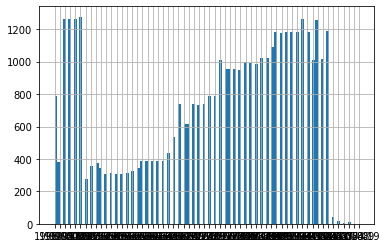

In [10]:
df_games[df_games['w_home'].isnull()]['season'].hist(bins=111)

In [11]:
df_games[df_games['w_home'].isnull()]['season'].value_counts().sort_index()

1950-51     381
1951-52     356
1952-53     375
1953-54     347
1954-55     310
1955-56     312
1956-57     308
1957-58     310
1958-59     311
1959-60     326
1960-61     342
1961-62     390
1962-63     390
1963-64     388
1964-65     387
1965-66     388
1966-67     437
1967-68     533
1968-69     614
1969-70     615
1970-71     738
1971-72     735
1972-73     739
1973-74     739
1974-75     786
1975-76     789
1976-77     956
1977-78     954
1978-79     956
1979-80     951
1980-81     996
1981-82     991
1982-83     987
1983-84    1023
1984-85    1012
1985-86    1012
1986-87    1015
1987-88    1024
1988-89    1088
1989-90    1180
1990-91    1176
1991-92    1181
1992-93    1184
1993-94    1185
1994-95    1181
1995-96    1258
1996-97    1260
1997-98    1260
1998-99     791
1999-00    1263
2000-01    1188
2001-02    1260
2002-03    1277
2003-04       7
2004-05      45
2005-06     277
2006-07      17
2007-08       9
2008-09       1
2018-19       1
Name: season, dtype: int64

In [12]:
#number of games actual: https://www.landofbasketball.com/results/2015_2016_scores.htm
df_games['season'].value_counts().sort_index()

1950-51     381
1951-52     356
1952-53     375
1953-54     347
1954-55     310
1955-56     312
1956-57     308
1957-58     310
1958-59     311
1959-60     326
1960-61     342
1961-62     390
1962-63     390
1963-64     388
1964-65     387
1965-66     388
1966-67     437
1967-68     533
1968-69     614
1969-70     615
1970-71     738
1971-72     735
1972-73     739
1973-74     739
1974-75     786
1975-76     789
1976-77     956
1977-78     954
1978-79     956
1979-80     951
1980-81     997
1981-82     991
1982-83     987
1983-84    1023
1984-85    1012
1985-86    1012
1986-87    1015
1987-88    1024
1988-89    1088
1989-90    1180
1990-91    1176
1991-92    1181
1992-93    1184
1993-94    1185
1994-95    1181
1995-96    1258
1996-97    1262
1997-98    1261
1998-99     791
1999-00    1265
2000-01    1261
2001-02    1261
2002-03    1278
2003-04    1272
2004-05    1315
2005-06    1423
2006-07    1428
2007-08    1420
2008-09    1430
2009-10    1430
2010-11    1430
2011-12    1105
2012-13 

In [13]:
#uniques
df_games[df_games['season'] == '2005-06']

,game_id,game_date,team_id_home,w_home,l_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_year,season_type,season
1751,20501225,2006-04-19,1610612741,NaN,NaN,NaN,240,49.0,90.0,0.544,7.0,20.0,0.350,22.0,29.0,1.0,14.0,43.0,57,31.0,3.0,2.0,15.0,28.0,127,2005,Regular Season,2005-06
1788,20500097,2005-11-14,1610612744,5.0,3.0,0.625,240,35.0,75.0,0.467,8.0,22.0,0.364,22.0,27.0,1.0,11.0,36.0,47,20.0,8.0,6.0,19.0,25.0,100,2005,Regular Season,2005-06
1789,20500079,2005-11-11,1610612744,NaN,NaN,NaN,240,29.0,75.0,0.387,9.0,29.0,0.310,19.0,27.0,1.0,11.0,34.0,45,24.0,5.0,7.0,12.0,20.0,86,2005,Regular Season,2005-06
1790,20500029,2005-11-04,1610612744,1.0,1.0,0.500,240,29.0,78.0,0.372,5.0,21.0,0.238,22.0,38.0,1.0,16.0,25.0,41,13.0,6.0,9.0,14.0,32.0,85,2005,Regular Season,2005-06
1791,20500017,2005-11-02,1610612744,1.0,0.0,1.000,240,43.0,74.0,0.581,7.0,19.0,0.368,29.0,45.0,1.0,11.0,27.0,38,24.0,10.0,8.0,19.0,21.0,122,2005,Regular Season,2005-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124403,20500450,2006-01-04,1610612749,17.0,12.0,0.586,240,31.0,83.0,0.373,5.0,19.0,0.263,17.0,20.0,1.0,9.0,34.0,43,17.0,7.0,2.0,17.0,19.0,84,2005,Regular Season,2005-06
124405,20500251,2005-12-06,1610612749,9.0,7.0,0.563,240,39.0,81.0,0.481,3.0,13.0,0.231,11.0,15.0,1.0,12.0,26.0,38,22.0,9.0,2.0,16.0,22.0,92,2005,Regular Season,2005-06
124406,20500199,2005-11-29,1610612749,7.0,6.0,0.538,265,40.0,82.0,0.488,6.0,11.0,0.545,27.0,35.0,1.0,14.0,32.0,46,21.0,6.0,5.0,15.0,22.0,113,2005,Regular Season,2005-06
124409,20500052,2005-11-08,1610612749,3.0,1.0,0.750,240,45.0,94.0,0.479,6.0,15.0,0.400,7.0,11.0,1.0,15.0,27.0,42,30.0,11.0,3.0,15.0,26.0,103,2005,Regular Season,2005-06


<AxesSubplot:>

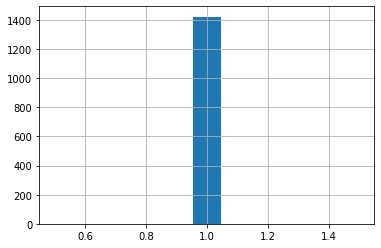

In [14]:
df_games[df_games['season'] == '2005-06'].game_id.value_counts().hist(bins=11)

In [15]:
df_games[df_games['season'] == '2005-06'][df_games['season_type'] == 'Regular Season']

C:\Users\Paul\anaconda3\lib\site-packages\ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


,game_id,game_date,team_id_home,w_home,l_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_year,season_type,season
1751,20501225,2006-04-19,1610612741,NaN,NaN,NaN,240,49.0,90.0,0.544,7.0,20.0,0.350,22.0,29.0,1.0,14.0,43.0,57,31.0,3.0,2.0,15.0,28.0,127,2005,Regular Season,2005-06
1788,20500097,2005-11-14,1610612744,5.0,3.0,0.625,240,35.0,75.0,0.467,8.0,22.0,0.364,22.0,27.0,1.0,11.0,36.0,47,20.0,8.0,6.0,19.0,25.0,100,2005,Regular Season,2005-06
1789,20500079,2005-11-11,1610612744,NaN,NaN,NaN,240,29.0,75.0,0.387,9.0,29.0,0.310,19.0,27.0,1.0,11.0,34.0,45,24.0,5.0,7.0,12.0,20.0,86,2005,Regular Season,2005-06
1790,20500029,2005-11-04,1610612744,1.0,1.0,0.500,240,29.0,78.0,0.372,5.0,21.0,0.238,22.0,38.0,1.0,16.0,25.0,41,13.0,6.0,9.0,14.0,32.0,85,2005,Regular Season,2005-06
1791,20500017,2005-11-02,1610612744,1.0,0.0,1.000,240,43.0,74.0,0.581,7.0,19.0,0.368,29.0,45.0,1.0,11.0,27.0,38,24.0,10.0,8.0,19.0,21.0,122,2005,Regular Season,2005-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124402,20500761,2006-02-14,1610612749,27.0,24.0,0.529,240,40.0,81.0,0.494,5.0,14.0,0.357,21.0,26.0,1.0,14.0,24.0,38,32.0,12.0,1.0,13.0,18.0,106,2005,Regular Season,2005-06
124403,20500450,2006-01-04,1610612749,17.0,12.0,0.586,240,31.0,83.0,0.373,5.0,19.0,0.263,17.0,20.0,1.0,9.0,34.0,43,17.0,7.0,2.0,17.0,19.0,84,2005,Regular Season,2005-06
124405,20500251,2005-12-06,1610612749,9.0,7.0,0.563,240,39.0,81.0,0.481,3.0,13.0,0.231,11.0,15.0,1.0,12.0,26.0,38,22.0,9.0,2.0,16.0,22.0,92,2005,Regular Season,2005-06
124406,20500199,2005-11-29,1610612749,7.0,6.0,0.538,265,40.0,82.0,0.488,6.0,11.0,0.545,27.0,35.0,1.0,14.0,32.0,46,21.0,6.0,5.0,15.0,22.0,113,2005,Regular Season,2005-06


In [16]:
df_games[df_games['season'] == '2005-06'].season_type.value_counts()

Regular Season    1230
Pre Season         103
Playoffs            89
All Star             1
Name: season_type, dtype: int64

In [17]:
#do we have betting data for preseason games?

In [18]:
df_totals = pd.read_csv('C:\\Users\\Paul\\sb\\Untitled Folder\\raw_data\\nba_betting_totals.csv')
df_totals

,game_id,book_name,book_id,team_id,a_team_id,total1,total2,price1,price2
0,21100131,Pinnacle Sports,238,1610612740,1610612743,192.0,192.0,-105.0,-105.0
1,21100131,5Dimes,19,1610612740,1610612743,192.0,192.0,-105.0,-105.0
2,21100131,Bookmaker,93,1610612740,1610612743,192.0,192.0,-110.0,-110.0
3,21100131,BetOnline,1096,1610612740,1610612743,191.5,191.5,-110.0,-110.0
4,21100131,Bovada,999996,1610612740,1610612743,192.0,192.0,-110.0,-110.0
...,...,...,...,...,...,...,...,...,...
131381,41700215,Heritage,169,1610612755,1610612738,204.5,204.5,-105.0,-105.0
131382,41700215,Intertops,180,1610612755,1610612738,205.0,205.0,-110.0,-110.0
131383,41700215,YouWager,139,1610612755,1610612738,204.5,204.5,-110.0,-110.0
131384,41700215,JustBet,1275,1610612755,1610612738,204.0,204.0,-110.0,-110.0


In [20]:
df_totals.game_id.unique()

array([21100131, 21100137, 21100148, ..., 41700213, 41700234, 41700215],
      dtype=int64)

In [23]:
type(df_totals.game_id.unique())

numpy.ndarray

In [24]:
len(df_totals.game_id.unique())

14918

In [25]:
df_games[df_games['season'] == '2005-06'][df_games['season_type'] == 'Pre Season']

C:\Users\Paul\anaconda3\lib\site-packages\ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


,game_id,game_date,team_id_home,w_home,l_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_year,season_type,season
14581,10500103,NaT,1610612738,3.0,4.0,0.429,240,36.0,69.0,0.522,2.0,10.0,0.200,27.0,37.0,1.0,8.0,17.0,25,24.0,10.0,8.0,21.0,35.0,101,2005,Pre Season,2005-06
14597,10500040,NaT,1610612765,NaN,NaN,NaN,240,31.0,74.0,0.419,2.0,8.0,0.250,27.0,36.0,1.0,13.0,32.0,45,20.0,2.0,6.0,13.0,25.0,91,2005,Pre Season,2005-06
14605,10500116,NaT,1610612762,2.0,5.0,0.286,240,28.0,69.0,0.406,3.0,12.0,0.250,24.0,34.0,1.0,10.0,33.0,43,17.0,5.0,9.0,26.0,24.0,83,2005,Pre Season,2005-06
14616,10500020,NaT,1610612766,NaN,NaN,NaN,240,24.0,78.0,0.308,3.0,14.0,0.214,25.0,32.0,1.0,17.0,25.0,42,14.0,11.0,5.0,19.0,35.0,76,2005,Pre Season,2005-06
14644,10500097,NaT,1610612759,2.0,7.0,0.222,240,33.0,70.0,0.471,5.0,12.0,0.417,15.0,23.0,1.0,7.0,29.0,36,23.0,6.0,6.0,14.0,24.0,86,2005,Pre Season,2005-06
14685,10500105,NaT,1610612745,6.0,1.0,0.857,240,29.0,67.0,0.433,6.0,13.0,0.462,24.0,33.0,1.0,10.0,36.0,46,17.0,7.0,6.0,19.0,20.0,88,2005,Pre Season,2005-06
14686,10500086,NaT,1610612745,5.0,1.0,0.833,240,29.0,64.0,0.453,2.0,10.0,0.200,15.0,21.0,1.0,7.0,32.0,39,19.0,7.0,4.0,19.0,23.0,75,2005,Pre Season,2005-06
30045,10500077,NaT,1610612738,2.0,4.0,0.333,240,32.0,67.0,0.478,3.0,9.0,0.333,23.0,30.0,1.0,6.0,39.0,45,23.0,18.0,10.0,19.0,20.0,90,2005,Pre Season,2005-06
30047,10500058,NaT,1610612738,NaN,NaN,NaN,240,24.0,63.0,0.381,5.0,10.0,0.500,29.0,43.0,1.0,11.0,33.0,44,17.0,10.0,3.0,27.0,33.0,82,2005,Pre Season,2005-06
30049,10500025,NaT,1610612738,NaN,NaN,NaN,240,29.0,60.0,0.483,3.0,9.0,0.333,46.0,60.0,1.0,12.0,32.0,44,20.0,7.0,2.0,25.0,32.0,107,2005,Pre Season,2005-06


In [26]:
series_pre = df_games[df_games['season'] == '2005-06'][df_games['season_type'] == 'Pre Season'].game_id
series_pre

C:\Users\Paul\anaconda3\lib\site-packages\ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


14581     10500103
14597     10500040
14605     10500116
14616     10500020
14644     10500097
14685     10500105
14686     10500086
30045     10500077
30047     10500058
30049     10500025
30159     10500068
30160     10500054
30180     10500074
30241     10500118
30264     10500065
30265     10500049
30266     10500013
30300     10500092
30301     10500002
30321     10500106
30364     10500121
30365     10500099
30366     10500063
30413     10500019
30453     10500035
30486     10500053
30502     10500081
30535     10500034
30536     10500120
30556     10500036
46211     10500113
46235     10500078
46256     10500089
46257     10500075
46301     10500050
46327     10500080
46362     10500027
46363     10500017
46372     10500119
61437     10500082
61452     10500003
61475     10500061
61589     10500009
61647     10500093
61702     10500085
61703     10500048
61704     10500041
61706     10500005
61802     10500083
61844     10500090
61845     10500064
61917     10500091
61959     10

In [27]:
type(series_pre)

pandas.core.series.Series

In [28]:
set_pre = set(series_pre)
set_pre

{10500001,
 10500002,
 10500003,
 10500005,
 10500007,
 10500008,
 10500009,
 10500010,
 10500011,
 10500013,
 10500016,
 10500017,
 10500018,
 10500019,
 10500020,
 10500021,
 10500023,
 10500024,
 10500025,
 10500026,
 10500027,
 10500028,
 10500029,
 10500030,
 10500032,
 10500034,
 10500035,
 10500036,
 10500037,
 10500039,
 10500040,
 10500041,
 10500042,
 10500043,
 10500044,
 10500045,
 10500046,
 10500048,
 10500049,
 10500050,
 10500051,
 10500052,
 10500053,
 10500054,
 10500055,
 10500056,
 10500057,
 10500058,
 10500060,
 10500061,
 10500062,
 10500063,
 10500064,
 10500065,
 10500066,
 10500067,
 10500068,
 10500069,
 10500070,
 10500071,
 10500072,
 10500073,
 10500074,
 10500075,
 10500076,
 10500077,
 10500078,
 10500079,
 10500080,
 10500081,
 10500082,
 10500083,
 10500084,
 10500085,
 10500086,
 10500087,
 10500088,
 10500089,
 10500090,
 10500091,
 10500092,
 10500093,
 10500094,
 10500095,
 10500096,
 10500097,
 10500099,
 10500100,
 10500101,
 10500102,
 10500103,

In [30]:
set_totals = set(df_totals.game_id)
set_totals

{21200896,
 21200897,
 21200898,
 21200899,
 21200900,
 21200901,
 21200902,
 21200903,
 21200904,
 21200905,
 21200906,
 21200907,
 21200908,
 21200909,
 21200910,
 21200911,
 21200912,
 21200913,
 21200914,
 21200915,
 21200916,
 21200917,
 21200918,
 21200919,
 21200920,
 21200921,
 21200922,
 21200923,
 21200924,
 21200925,
 21200926,
 21200927,
 21200928,
 21200929,
 21200930,
 21200931,
 21200932,
 21200933,
 21200934,
 21200935,
 21200936,
 21200937,
 21200938,
 21200939,
 21200940,
 21200941,
 21200942,
 21200943,
 21200944,
 21200945,
 21200946,
 21200947,
 21200948,
 21200949,
 21200950,
 21200951,
 21200952,
 21200953,
 21200954,
 21200955,
 21200956,
 21200957,
 21200958,
 21200959,
 21200960,
 21200961,
 21200962,
 21200963,
 21200964,
 21200965,
 21200966,
 21200967,
 21200968,
 21200969,
 21200970,
 21200971,
 21200972,
 21200973,
 21200974,
 21200975,
 21200976,
 21200977,
 21200978,
 21200979,
 21200980,
 21200981,
 21200982,
 21200983,
 21200984,
 21200985,
 21200986,

In [31]:
set_totals.intersection(set_pre)

set()

In [32]:
set_pre.intersection(set_totals)

set()

In [34]:
series_reg = df_games[df_games['season'] == '2005-06'][df_games['season_type'] == 'Regular Season'].game_id
series_reg


C:\Users\Paul\anaconda3\lib\site-packages\ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


1751      20501225
1788      20500097
1789      20500079
1790      20500029
1791      20500017
            ...   
124402    20500761
124403    20500450
124405    20500251
124406    20500199
124409    20500052
Name: game_id, Length: 1230, dtype: int64

In [35]:
set_reg = set(series_reg)

In [36]:
set_totals.intersection(set_reg)

set()

In [37]:
set_reg.intersection(set_totals)

set()

In [38]:
{1, 2, 3}.intersection({1, 2})

{1, 2}

In [39]:
set_reg

{20500001,
 20500002,
 20500003,
 20500004,
 20500005,
 20500006,
 20500007,
 20500008,
 20500009,
 20500010,
 20500011,
 20500012,
 20500013,
 20500014,
 20500015,
 20500016,
 20500017,
 20500018,
 20500019,
 20500020,
 20500021,
 20500022,
 20500023,
 20500024,
 20500025,
 20500026,
 20500027,
 20500028,
 20500029,
 20500030,
 20500031,
 20500032,
 20500033,
 20500034,
 20500035,
 20500036,
 20500037,
 20500038,
 20500039,
 20500040,
 20500041,
 20500042,
 20500043,
 20500044,
 20500045,
 20500046,
 20500047,
 20500048,
 20500049,
 20500050,
 20500051,
 20500052,
 20500053,
 20500054,
 20500055,
 20500056,
 20500057,
 20500058,
 20500059,
 20500060,
 20500061,
 20500062,
 20500063,
 20500064,
 20500065,
 20500066,
 20500067,
 20500068,
 20500069,
 20500070,
 20500071,
 20500072,
 20500073,
 20500074,
 20500075,
 20500076,
 20500077,
 20500078,
 20500079,
 20500080,
 20500081,
 20500082,
 20500083,
 20500084,
 20500085,
 20500086,
 20500087,
 20500088,
 20500089,
 20500090,
 20500091,

In [40]:
set_totals

{21200896,
 21200897,
 21200898,
 21200899,
 21200900,
 21200901,
 21200902,
 21200903,
 21200904,
 21200905,
 21200906,
 21200907,
 21200908,
 21200909,
 21200910,
 21200911,
 21200912,
 21200913,
 21200914,
 21200915,
 21200916,
 21200917,
 21200918,
 21200919,
 21200920,
 21200921,
 21200922,
 21200923,
 21200924,
 21200925,
 21200926,
 21200927,
 21200928,
 21200929,
 21200930,
 21200931,
 21200932,
 21200933,
 21200934,
 21200935,
 21200936,
 21200937,
 21200938,
 21200939,
 21200940,
 21200941,
 21200942,
 21200943,
 21200944,
 21200945,
 21200946,
 21200947,
 21200948,
 21200949,
 21200950,
 21200951,
 21200952,
 21200953,
 21200954,
 21200955,
 21200956,
 21200957,
 21200958,
 21200959,
 21200960,
 21200961,
 21200962,
 21200963,
 21200964,
 21200965,
 21200966,
 21200967,
 21200968,
 21200969,
 21200970,
 21200971,
 21200972,
 21200973,
 21200974,
 21200975,
 21200976,
 21200977,
 21200978,
 21200979,
 21200980,
 21200981,
 21200982,
 21200983,
 21200984,
 21200985,
 21200986,

In [47]:
df_game_id_totals = df_totals.game_id.value_counts().to_frame().reset_index().drop(columns='game_id').rename(columns={'index':'game_id'})
df_game_id_totals

,game_id
0,21401224
1,21500364
2,21500704
3,21601041
4,21600509
...,...
14913,20600319
14914,20600324
14915,20600135
14916,20600315


In [50]:
df_intersection = pd.merge(df_game_id_totals, df_games, how='inner')
df_intersection

,game_id,game_date,team_id_home,w_home,l_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_year,season_type,season
0,21401224,2015-04-15,1610612751,38.0,44.0,0.463,240,39.0,80.0,0.488,9.0,24.0,0.375,14.0,23.0,1.0,7.0,33.0,40,25.0,8.0,5.0,12.0,12.0,101,2014,Regular Season,2014-15
1,21500364,2015-12-14,1610612759,21.0,5.0,0.808,240,42.0,75.0,0.560,9.0,21.0,0.429,25.0,27.0,1.0,9.0,39.0,48,24.0,6.0,2.0,11.0,17.0,118,2015,Regular Season,2015-16
2,21500704,2016-01-29,1610612762,21.0,25.0,0.457,240,40.0,76.0,0.526,10.0,25.0,0.400,13.0,16.0,1.0,10.0,30.0,40,24.0,8.0,5.0,13.0,21.0,103,2015,Regular Season,2015-16
3,21601041,2017-03-19,1610612748,34.0,36.0,0.486,240,41.0,88.0,0.466,9.0,30.0,0.300,13.0,20.0,1.0,13.0,26.0,39,18.0,8.0,8.0,9.0,22.0,104,2016,Regular Season,2016-17
4,21600509,2017-01-01,1610612748,10.0,25.0,0.286,240,35.0,77.0,0.455,14.0,26.0,0.538,14.0,18.0,1.0,3.0,31.0,34,25.0,6.0,4.0,10.0,22.0,98,2016,Regular Season,2016-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14913,20600319,2006-12-13,1610612751,9.0,12.0,0.429,240,38.0,77.0,0.494,10.0,22.0,0.455,22.0,30.0,1.0,15.0,25.0,40,31.0,11.0,2.0,16.0,23.0,108,2006,Regular Season,2006-07
14914,20600324,2006-12-13,1610612742,15.0,7.0,0.682,240,39.0,65.0,0.600,4.0,11.0,0.364,28.0,33.0,1.0,7.0,32.0,39,23.0,8.0,7.0,19.0,28.0,110,2006,Regular Season,2006-07
14915,20600135,2006-11-18,1610612750,NaN,NaN,NaN,240,35.0,85.0,0.412,5.0,14.0,0.357,21.0,27.0,1.0,18.0,32.0,50,25.0,7.0,4.0,15.0,16.0,96,2006,Regular Season,2006-07
14916,20600315,2006-12-13,1610612753,15.0,9.0,0.625,240,32.0,85.0,0.376,2.0,12.0,0.167,18.0,23.0,1.0,20.0,23.0,43,10.0,7.0,0.0,14.0,21.0,84,2006,Regular Season,2006-07


In [51]:
df_intersection.season_type.value_counts()

Regular Season    13891
Playoffs            995
Pre Season           32
Name: season_type, dtype: int64

In [54]:
df_intersection[df_intersection['season'] == '2016-17']

,game_id,game_date,team_id_home,w_home,l_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_year,season_type,season
3,21601041,2017-03-19,1610612748,34.0,36.0,0.486,240,41.0,88.0,0.466,9.0,30.0,0.300,13.0,20.0,1.0,13.0,26.0,39,18.0,8.0,8.0,9.0,22.0,104,2016,Regular Season,2016-17
4,21600509,2017-01-01,1610612748,10.0,25.0,0.286,240,35.0,77.0,0.455,14.0,26.0,0.538,14.0,18.0,1.0,3.0,31.0,34,25.0,6.0,4.0,10.0,22.0,98,2016,Regular Season,2016-17
11,21600637,2017-01-19,1610612748,13.0,30.0,0.302,240,35.0,73.0,0.479,9.0,20.0,0.450,20.0,29.0,1.0,6.0,34.0,40,16.0,4.0,1.0,13.0,15.0,99,2016,Regular Season,2016-17
13,21600913,2017-03-03,1610612737,34.0,27.0,0.557,240,49.0,91.0,0.538,10.0,26.0,0.385,22.0,30.0,1.0,11.0,32.0,43,30.0,7.0,4.0,12.0,15.0,130,2016,Regular Season,2016-17
16,21600765,2017-02-05,1610612751,9.0,42.0,0.176,240,32.0,76.0,0.421,13.0,34.0,0.382,18.0,21.0,1.0,7.0,35.0,42,19.0,8.0,7.0,21.0,19.0,95,2016,Regular Season,2016-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8076,21600980,2017-03-11,1610612759,51.0,14.0,0.785,240,40.0,77.0,0.519,12.0,27.0,0.444,15.0,18.0,1.0,7.0,39.0,46,27.0,6.0,7.0,18.0,18.0,107,2016,Regular Season,2016-17
8086,21601187,2017-04-07,1610612747,24.0,55.0,0.304,240,38.0,86.0,0.442,4.0,24.0,0.167,18.0,25.0,1.0,16.0,25.0,41,20.0,12.0,1.0,14.0,15.0,98,2016,Regular Season,2016-17
8087,21600596,2017-01-13,1610612750,14.0,26.0,0.350,240,39.0,86.0,0.453,5.0,18.0,0.278,13.0,14.0,1.0,9.0,33.0,42,21.0,11.0,6.0,15.0,22.0,96,2016,Regular Season,2016-17
8090,21601000,2017-03-14,1610612751,12.0,54.0,0.182,240,33.0,71.0,0.465,12.0,24.0,0.500,26.0,30.0,1.0,4.0,28.0,32,20.0,6.0,6.0,18.0,23.0,104,2016,Regular Season,2016-17


In [56]:
df_intersection.season.value_counts().sort_index()

2006-07    1203
2007-08    1221
2008-09    1271
2009-10    1269
2010-11    1213
2011-12    1104
2012-13    1302
2013-14    1300
2014-15    1283
2015-16    1278
2016-17    1264
2017-18    1210
Name: season, dtype: int64

In [ ]:
#2006-07 to 2017-18 are the seasons of interest and looking at just regular season and playoffs




In [66]:
df_intersection[df_intersection.season_type == 'Pre Season']['season'].value_counts()

2011-12    30
2017-18     2
Name: season, dtype: int64

In [68]:
df_intersection = df_intersection[df_intersection.season_type != 'Pre Season']
df_intersection

,game_id,game_date,team_id_home,w_home,l_home,w_pct_home,min_home,fgm_home,fga_home,fg_pct_home,fg3m_home,fg3a_home,fg3_pct_home,ftm_home,fta_home,ft_pct_home,oreb_home,dreb_home,reb_home,ast_home,stl_home,blk_home,tov_home,pf_home,pts_home,season_year,season_type,season
0,21401224,2015-04-15,1610612751,38.0,44.0,0.463,240,39.0,80.0,0.488,9.0,24.0,0.375,14.0,23.0,1.0,7.0,33.0,40,25.0,8.0,5.0,12.0,12.0,101,2014,Regular Season,2014-15
1,21500364,2015-12-14,1610612759,21.0,5.0,0.808,240,42.0,75.0,0.560,9.0,21.0,0.429,25.0,27.0,1.0,9.0,39.0,48,24.0,6.0,2.0,11.0,17.0,118,2015,Regular Season,2015-16
2,21500704,2016-01-29,1610612762,21.0,25.0,0.457,240,40.0,76.0,0.526,10.0,25.0,0.400,13.0,16.0,1.0,10.0,30.0,40,24.0,8.0,5.0,13.0,21.0,103,2015,Regular Season,2015-16
3,21601041,2017-03-19,1610612748,34.0,36.0,0.486,240,41.0,88.0,0.466,9.0,30.0,0.300,13.0,20.0,1.0,13.0,26.0,39,18.0,8.0,8.0,9.0,22.0,104,2016,Regular Season,2016-17
4,21600509,2017-01-01,1610612748,10.0,25.0,0.286,240,35.0,77.0,0.455,14.0,26.0,0.538,14.0,18.0,1.0,3.0,31.0,34,25.0,6.0,4.0,10.0,22.0,98,2016,Regular Season,2016-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14913,20600319,2006-12-13,1610612751,9.0,12.0,0.429,240,38.0,77.0,0.494,10.0,22.0,0.455,22.0,30.0,1.0,15.0,25.0,40,31.0,11.0,2.0,16.0,23.0,108,2006,Regular Season,2006-07
14914,20600324,2006-12-13,1610612742,15.0,7.0,0.682,240,39.0,65.0,0.600,4.0,11.0,0.364,28.0,33.0,1.0,7.0,32.0,39,23.0,8.0,7.0,19.0,28.0,110,2006,Regular Season,2006-07
14915,20600135,2006-11-18,1610612750,NaN,NaN,NaN,240,35.0,85.0,0.412,5.0,14.0,0.357,21.0,27.0,1.0,18.0,32.0,50,25.0,7.0,4.0,15.0,16.0,96,2006,Regular Season,2006-07
14916,20600315,2006-12-13,1610612753,15.0,9.0,0.625,240,32.0,85.0,0.376,2.0,12.0,0.167,18.0,23.0,1.0,20.0,23.0,43,10.0,7.0,0.0,14.0,21.0,84,2006,Regular Season,2006-07


In [69]:
df_intersection.game_id.value_counts()

21600253    1
20800185    1
20800217    1
20900568    1
21500631    1
           ..
21400939    1
21300586    1
20901223    1
20800870    1
21200896    1
Name: game_id, Length: 14886, dtype: int64

<font color='red'> hereherehereherehereherehereherehereherehereherehereherehereherehereherehereherehereherehereherehereherehereherehereherehere</font>

In [ ]:
#add columns to original dataframe
df_games.columns

In [ ]:
away_column_names = empty_df.columns.drop(['game_id', 'game_date', 'is_home',
                                           'team_id_away', 'is_home'])
away_column_names

In [ ]:
cols_numeric = empty_df.select_dtypes([np.number]).columns.drop('game_id')
cols_numeric

In [ ]:
df_games.info()

In [ ]:
for column in cols_numeric:
    df_games[column] = 0
df_games

In [ ]:
empty_df.drop(columns=['is_home', 'season_type', 'season'], inplace=True)
empty_df.info()

In [ ]:
df = pd.concat([df_games, empty_df])
df

In [ ]:
df.info()

In [ ]:
import time
start  = time.time()
df = df.groupby(['game_id', 'game_date']).sum()
t = time.time() - start
df

In [ ]:
t

In [ ]:
df

In [ ]:
#pd.merge(df_games, empty_df, on=['game_id', 'game_date']).set_index(['game_id', 'game_date'])

In [ ]:
#pd.merge(df_games, empty_df, on=['game_id', 'game_date']).set_index(['game_id', 'game_date'])

In [ ]:
df_years = pd.to_datetime(df_games.game_date)
df_years

In [ ]:
df_years.dt.year.value_counts().sort_values()

In [ ]:
df_teams = pd.read_csv('C:\\Users\\Paul\\sb\\Untitled Folder\\raw_data\\nba_teams_all.csv')
df_teams.head()

In [ ]:
df_games = df_games[df_games.season_type == 'Regular Season'][(df_games.season == '2006-07') |
                                                   (df_games.season == '2007-08') |
                                                   (df_games.season == '2008-09') |
                                                   (df_games.season == '2009-10') | 
                                                   (df_games.season == '2010-11') |
                                                   (df_games.season == '2011-12') |
                                                   (df_games.season == '2012-13') |
                                                   (df_games.season == '2013-14') |
                                                   (df_games.season == '2014-15') |
                                                   (df_games.season == '2015-16') | 
                                                   (df_games.season == '2016-17') | 
                                                   (df_games.season == '2017-18')]
df_games

In [ ]:
df_games = pd.merge(df_games
         , df_teams[['team_id','abbreviation']], on=['team_id'], how='left')
df_games

In [ ]:
df_games.sort_values('game_id')

In [ ]:
df_games[df_games['game_id'] == 20600001]

In [ ]:
df_games = df_games[df_games['game_date'].notnull()]

In [ ]:
df_games.shape

In [ ]:
df_games.sort_values('game_id', inplace=True)

In [ ]:
df_games = df_games.reset_index().drop(columns='index')
df_games

In [ ]:
game_ids = df_games.game_id.unique()
game_ids

In [ ]:
df_games['game_date'] = pd.to_datetime(df_games['game_date'])

In [ ]:
def build_game_date_indexed_rows():
    df_empty = pd.DataFrame({})

    for id_ in game_ids:

        visitor_ = df_games[df_games['is_home'] == 'f'][df_games['game_id'] == id_]
        home_ = df_games[df_games['is_home'] == 't'][df_games['game_id'] == id_]


        #visitor team abbreviation
        s0 = str('_') + df_games[df_games['game_id'] == id_][df_games['is_home'] == 'f']['abbreviation'].iloc[0]

        #home team abbreviation
        s1 = str('_') + df_games[df_games['game_id'] == id_][df_games['is_home'] == 't']['abbreviation'].iloc[0]


        df_single_game = pd.merge(visitor_, home_, on=['game_id', 'game_date'], how='inner', suffixes=[s0, s1])

        df_empty = pd.concat([df_empty, df_single_game])
    
    df_empty = df_empty.reset_index().drop(columns='index').set_index(['game_id', 'game_date'])
    return df_empty

In [ ]:
import time
start_time = time.time()


In [ ]:

df = build_game_date_indexed_rows()

In [ ]:
df

In [ ]:
print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
print("--- %s minutes ---" % ((time.time() - start_time) / 60))

In [ ]:
df.iloc[:, 1]

In [ ]:
datapath = 'C:\\Users\\Paul\\sb\\DSCapstone2\\processed_data'

if not os.path.exists(datapath):
    os.mkdir(datapath)
    
datapath_df = os.path.join(datapath, '1games_df.csv')
if not os.path.exists(datapath_df):
    df.to_csv(datapath_df, index=True)
